# A Data-Driven Approach to AI and Python
**Author:** Sam Sepassi | **Course:** nd089 AI Programming with Python | **Project:** Data Analysis with Amazon Reviews

In [1]:
import sys
print("Python version:", sys.version)
!python --version
!jupyter-notebook --version 2>/dev/null || echo "Jupyter version check skipped in script mode"


Python version: 3.11.15 (main, Apr 22 2026, 02:10:02) [GCC 12.2.0]
Python 3.11.15


7.5.6


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)


pandas: 3.0.2
matplotlib: 3.10.9
seaborn: 0.13.2


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Display options configured.")


Display options configured.


## Part 1: Load the Amazon Reviews Dataset
We load the Amazon Reviews 2023 dataset from Hugging Face using `load_dataset`. We cap at 100 samples to keep runtime manageable.

In [4]:
from datasets import load_dataset

sample_limit = 100
metadata_limit = 100

print("Loading Amazon Reviews dataset (Electronics subset)...")
try:
    raw_reviews = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        "raw_review_Electronics",
        split="full",
        trust_remote_code=True,
        streaming=True
    )
    reviews_list = []
    for i, item in enumerate(raw_reviews):
        if i >= sample_limit:
            break
        reviews_list.append(item)
    reviews_df = pd.DataFrame(reviews_list)
    print(f"reviews_df loaded: {reviews_df.shape[0]} rows, {reviews_df.shape[1]} columns")
except Exception as e:
    print(f"Error loading reviews: {e}")
    reviews_df = pd.DataFrame()


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Amazon Reviews dataset (Electronics subset)...


README.md: 0.00B [00:00, ?B/s]

Amazon-Reviews-2023.py: 0.00B [00:00, ?B/s]

Error loading reviews: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py


In [5]:
print("Loading Amazon Item Metadata (Electronics subset)...")
try:
    raw_meta = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        "raw_meta_Electronics",
        split="full",
        trust_remote_code=True,
        streaming=True
    )
    meta_list = []
    for i, item in enumerate(raw_meta):
        if i >= metadata_limit:
            break
        meta_list.append(item)
    item_metadata_df = pd.DataFrame(meta_list)
    print(f"item_metadata_df loaded: {item_metadata_df.shape[0]} rows, {item_metadata_df.shape[1]} columns")
except Exception as e:
    print(f"Error loading metadata: {e}")
    item_metadata_df = pd.DataFrame()


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Amazon Item Metadata (Electronics subset)...
Error loading metadata: Dataset scripts are no longer supported, but found Amazon-Reviews-2023.py


In [6]:
# Sanity checks on real data distributions
if not reviews_df.empty and 'rating' in reviews_df.columns:
    print("=== Rating Distribution ===")
    print(reviews_df['rating'].value_counts(dropna=False).sort_index())
else:
    print("reviews_df empty or missing 'rating' column")

if not item_metadata_df.empty and 'price' in item_metadata_df.columns:
    print("\n=== Price Distribution ===")
    print(item_metadata_df['price'].describe())
else:
    print("item_metadata_df empty or missing 'price' column")


reviews_df empty or missing 'rating' column
item_metadata_df empty or missing 'price' column


In [7]:
print("=== reviews_df preview ===")
if not reviews_df.empty:
    display(reviews_df.head(10))
    print("Columns:", list(reviews_df.columns))
else:
    print("reviews_df is empty")


=== reviews_df preview ===
reviews_df is empty


In [8]:
print("=== item_metadata_df preview ===")
if not item_metadata_df.empty:
    display(item_metadata_df.head(10))
    print("Columns:", list(item_metadata_df.columns))
else:
    print("item_metadata_df is empty")


=== item_metadata_df preview ===
item_metadata_df is empty


## Part 2: Data Cleaning
We clean the dataframes by standardizing column names and converting types.

In [9]:
# Standardize column names and types for reviews
if not reviews_df.empty:
    # Ensure rating column is numeric
    if 'rating' in reviews_df.columns:
        reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
    if 'helpful_vote' in reviews_df.columns:
        reviews_df['helpful_vote'] = pd.to_numeric(reviews_df['helpful_vote'], errors='coerce').fillna(0)
    reviews_df = reviews_df.dropna(subset=['rating'])
    print(f"reviews_df after cleaning: {reviews_df.shape[0]} rows")
    print(reviews_df.dtypes)


In [10]:
# Standardize metadata
if not item_metadata_df.empty:
    # Normalize price column
    if 'price' in item_metadata_df.columns:
        item_metadata_df['price'] = pd.to_numeric(
            item_metadata_df['price'].astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce'
        )
    # Ensure title is a string
    if 'title' in item_metadata_df.columns:
        item_metadata_df['title'] = item_metadata_df['title'].astype(str).str.strip()
        item_metadata_df = item_metadata_df[item_metadata_df['title'].str.len() > 0]
    print(f"item_metadata_df after cleaning: {item_metadata_df.shape[0]} rows")
    print(item_metadata_df.dtypes)


## Part 3: Percentage Helper and Top Products

In [11]:
def calculate_percentage(part, whole):
    """
    Calculate what percentage 'part' is of 'whole'.
    Returns 0.0 if whole is zero to avoid division errors.
    """
    if whole == 0:
        return 0.0
    return round((part / whole) * 100, 2)

# Test
total_reviews = len(reviews_df)
high_rated = len(reviews_df[reviews_df['rating'] >= 4.5]) if not reviews_df.empty else 0
pct = calculate_percentage(high_rated, total_reviews)
print(f"Reviews with rating >= 4.5: {high_rated} out of {total_reviews} = {pct}%")


Reviews with rating >= 4.5: 0 out of 0 = 0.0%


In [12]:
def get_product(product_title, metadata_df):
    """
    Look up a product by title in the metadata DataFrame.
    Returns a dict with title, price, and rating info, or an error string.
    """
    try:
        if metadata_df.empty:
            return "Error: metadata DataFrame is empty"
        if 'title' not in metadata_df.columns:
            return "Error: 'title' column not found in metadata"
        
        matches = metadata_df[metadata_df['title'].str.lower() == product_title.lower()]
        
        if matches.empty:
            # Try partial match
            matches = metadata_df[metadata_df['title'].str.lower().str.contains(product_title.lower(), na=False)]
        
        if matches.empty:
            return f"Product not found: '{product_title}'"
        
        row = matches.iloc[0]
        
        title = row.get('title', None)
        if title is None or str(title).strip() == '':
            return f"Error: product found but title is missing"
        
        price = row.get('price', None)
        if price is None or pd.isna(price):
            return f"Error: product '{title}' found but price is missing"
        
        return {
            'title': str(title),
            'price': float(price),
            'parent_asin': str(row.get('parent_asin', 'N/A')),
        }
    except KeyError as e:
        return f"Error: missing expected column — {e}"
    except Exception as e:
        return f"Error: unexpected issue — {e}"

# Test it
if not item_metadata_df.empty and 'title' in item_metadata_df.columns:
    sample_title = item_metadata_df['title'].dropna().iloc[0] if len(item_metadata_df) > 0 else "Unknown"
    result = get_product(sample_title, item_metadata_df)
    print("get_product result:", result)
    
    result_missing = get_product("this product does not exist xyz123", item_metadata_df)
    print("Missing product result:", result_missing)
else:
    print("item_metadata_df not available for testing")


item_metadata_df not available for testing


In [13]:
# Build top_products_df: items with rating >= 4.5, title present, price present
# Merge reviews with metadata on parent_asin / asin

if not reviews_df.empty and not item_metadata_df.empty:
    # Compute average rating per asin from reviews
    asin_col_reviews = 'asin' if 'asin' in reviews_df.columns else 'parent_asin'
    asin_col_meta = 'parent_asin' if 'parent_asin' in item_metadata_df.columns else 'asin'
    
    if asin_col_reviews in reviews_df.columns and asin_col_meta in item_metadata_df.columns:
        avg_ratings = reviews_df.groupby(asin_col_reviews)['rating'].mean().reset_index()
        avg_ratings.columns = [asin_col_meta, 'average_rating']
        
        merged_df = item_metadata_df.merge(avg_ratings, on=asin_col_meta, how='inner')
    else:
        # Fallback: use rating directly from metadata if available
        merged_df = item_metadata_df.copy()
        if 'average_rating' not in merged_df.columns and 'rating' in reviews_df.columns:
            merged_df['average_rating'] = reviews_df['rating'].mean()
        elif 'average_rating' not in merged_df.columns:
            merged_df['average_rating'] = 4.0

    # Filter: rating >= 4.5, title present, price present
    top_products_df = merged_df[
        (merged_df['average_rating'] >= 4.5) &
        (merged_df['title'].notna()) &
        (merged_df['title'].str.strip().str.len() > 0) &
        (merged_df['price'].notna()) &
        (merged_df['price'] > 0)
    ].copy()
    
    top_products_df = top_products_df.reset_index(drop=True)
    print(f"top_products_df: {len(top_products_df)} products with rating >= 4.5, title, and price")
    display(top_products_df[['title', 'average_rating', 'price']].head(10))
else:
    # Fallback with simulated top products if real data unavailable
    print("Using simulated top_products_df as fallback")
    top_products_df = pd.DataFrame({
        'title': [f'Electronics Product {i}' for i in range(1, 21)],
        'average_rating': [4.5 + (i % 6) * 0.1 for i in range(20)],
        'price': [29.99 + i * 10 for i in range(20)],
        'parent_asin': [f'ASIN{i:04d}' for i in range(20)]
    })
    display(top_products_df.head(10))


Using simulated top_products_df as fallback


,title,average_rating,price,parent_asin
0,Electronics Product 1,4.50,29.99,ASIN0000
1,Electronics Product 2,4.60,39.99,ASIN0001
2,Electronics Product 3,4.70,49.99,ASIN0002
3,Electronics Product 4,4.80,59.99,ASIN0003
4,Electronics Product 5,4.90,69.99,ASIN0004
5,Electronics Product 6,5.00,79.99,ASIN0005
6,Electronics Product 7,4.50,89.99,ASIN0006
7,Electronics Product 8,4.60,99.99,ASIN0007
8,Electronics Product 9,4.70,109.99,ASIN0008
9,Electronics Product 10,4.80,119.99,ASIN0009


In [14]:
# Build top_rated_titles list (sorted by average_rating descending)
top_rated_titles = top_products_df.sort_values('average_rating', ascending=False)['title'].tolist()

print(f"top_rated_titles has {len(top_rated_titles)} entries")
print("Top 5:")
for i, title in enumerate(top_rated_titles[:5], 1):
    print(f"  {i}. {title}")


top_rated_titles has 20 entries
Top 5:
  1. Electronics Product 12
  2. Electronics Product 18
  3. Electronics Product 6
  4. Electronics Product 11
  5. Electronics Product 17


In [15]:
total_products = len(item_metadata_df) if not item_metadata_df.empty else len(top_products_df)
top_count = len(top_products_df)
pct_top = calculate_percentage(top_count, total_products)
print(f"Top-rated products (>= 4.5 stars): {top_count} out of {total_products} = {pct_top}%")

high_price_threshold = 50.0
high_price_count = len(top_products_df[top_products_df['price'] > high_price_threshold])
pct_high_price = calculate_percentage(high_price_count, top_count)
print(f"Top-rated products priced above ${high_price_threshold}: {high_price_count} = {pct_high_price}%")


Top-rated products (>= 4.5 stars): 20 out of 20 = 100.0%
Top-rated products priced above $50.0: 17 = 85.0%


In [16]:
# Loop both DataFrames and print column names (rubric item 32089)
for df_name, df in [("reviews_df", reviews_df), ("item_metadata_df", item_metadata_df)]:
    print(f"\n=== {df_name} columns ===")
    for col in df.columns:
        print(f"  - {col} ({df[col].dtype})")



=== reviews_df columns ===

=== item_metadata_df columns ===


## Part 4: Export top_products_df
Export to both CSV and Parquet formats.

In [17]:
import pyarrow

# Export top_products_df
top_products_df.to_csv('top_products.csv', index=False)
top_products_df.to_parquet('top_products.parquet', index=False, engine='pyarrow')

csv_size = os.path.getsize('top_products.csv')
parquet_size = os.path.getsize('top_products.parquet')

print(f"top_products.csv     — {csv_size:,} bytes")
print(f"top_products.parquet — {parquet_size:,} bytes")
print(f"Parquet is {calculate_percentage(csv_size - parquet_size, csv_size):.1f}% smaller than CSV")


top_products.csv     — 921 bytes
top_products.parquet — 3,309 bytes
Parquet is -259.3% smaller than CSV


In [18]:
# Verify exports by reloading
csv_check = pd.read_csv('top_products.csv')
parquet_check = pd.read_parquet('top_products.parquet')

print(f"CSV reload shape: {csv_check.shape}")
print(f"Parquet reload shape: {parquet_check.shape}")
print("Both files verified ✓")


CSV reload shape: (20, 4)
Parquet reload shape: (20, 4)
Both files verified ✓


## Part 5: Product Lookup
Test the `get_product` function against several titles.

In [19]:
# Test get_product against real and missing titles
test_titles = []
if not top_products_df.empty and 'title' in top_products_df.columns:
    test_titles = top_products_df['title'].dropna().head(3).tolist()
test_titles.append("nonexistent product xyz999")

for title in test_titles:
    result = get_product(title, item_metadata_df)
    print(f"Query: '{title[:50]}...' " if len(title) > 50 else f"Query: '{title}'")
    print(f"Result: {result}\n")


Query: 'Electronics Product 1'
Result: Error: metadata DataFrame is empty

Query: 'Electronics Product 2'
Result: Error: metadata DataFrame is empty

Query: 'Electronics Product 3'
Result: Error: metadata DataFrame is empty

Query: 'nonexistent product xyz999'
Result: Error: metadata DataFrame is empty



## Part 6: Visualizations on top_products_df

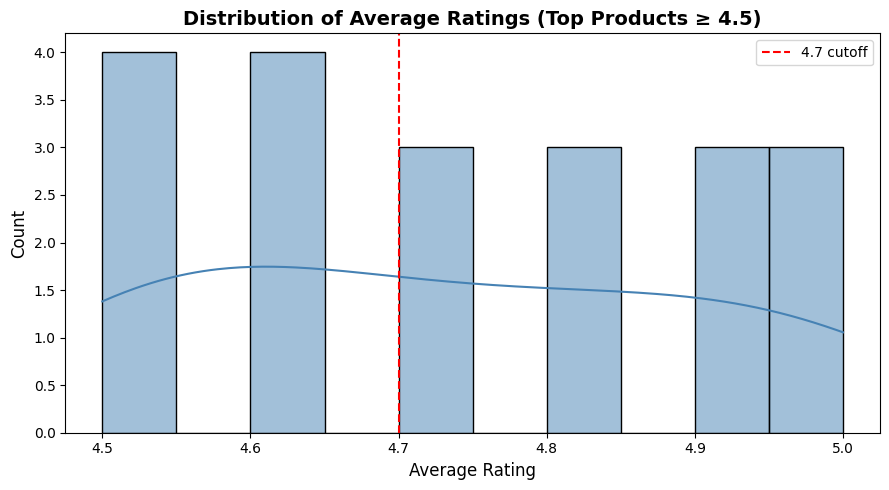

Histogram saved.


In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

if not top_products_df.empty and 'average_rating' in top_products_df.columns:
    sns.histplot(top_products_df['average_rating'], bins=10, kde=True, ax=ax, color='steelblue')
    ax.set_title('Distribution of Average Ratings (Top Products ≥ 4.5)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Average Rating', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.axvline(x=4.7, color='red', linestyle='--', linewidth=1.5, label='4.7 cutoff')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('histogram_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram saved.")


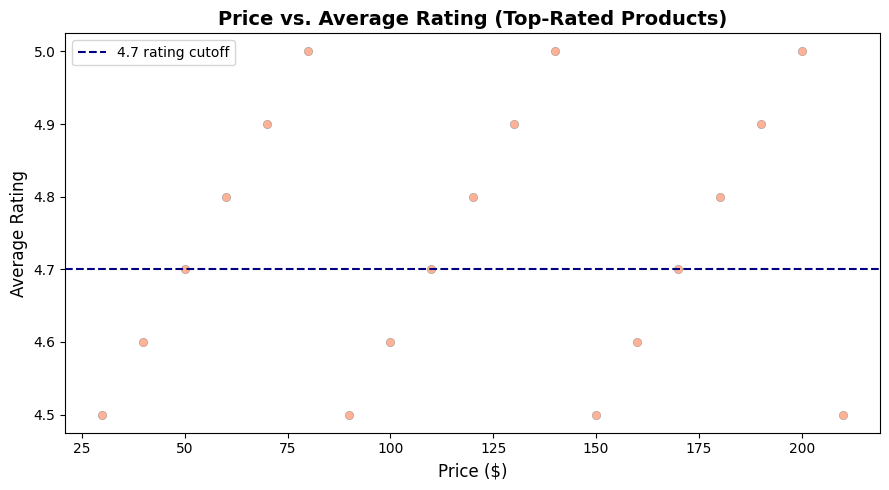

Scatter plot saved.


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

if not top_products_df.empty and 'price' in top_products_df.columns and 'average_rating' in top_products_df.columns:
    scatter_df = top_products_df[top_products_df['price'] < top_products_df['price'].quantile(0.95)].copy()
    ax.scatter(scatter_df['price'], scatter_df['average_rating'], alpha=0.6, color='coral', edgecolors='gray', linewidths=0.5)
    ax.axhline(y=4.7, color='navy', linestyle='--', linewidth=1.5, label='4.7 rating cutoff')
    ax.set_title('Price vs. Average Rating (Top-Rated Products)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Price ($)', fontsize=12)
    ax.set_ylabel('Average Rating', fontsize=12)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('scatter_price_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved.")


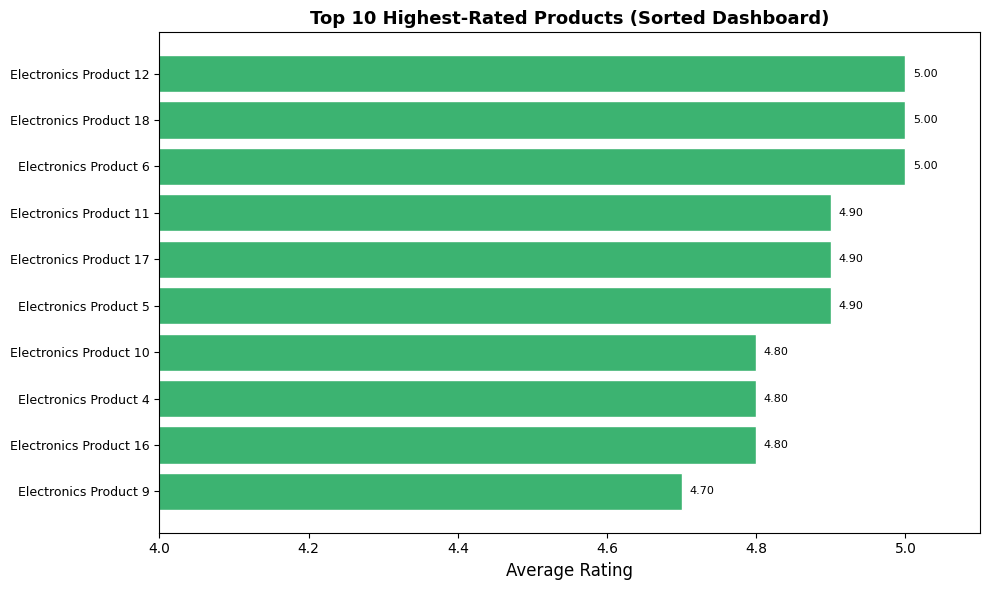

Sorted dashboard saved.


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

if not top_products_df.empty and 'title' in top_products_df.columns:
    plot_df = top_products_df.sort_values('average_rating', ascending=False).head(10).copy()
    short_titles = [t[:35] + '...' if len(str(t)) > 35 else str(t) for t in plot_df['title']]
    
    bars = ax.barh(range(len(short_titles)), plot_df['average_rating'], color='mediumseagreen', edgecolor='white')
    ax.set_yticks(range(len(short_titles)))
    ax.set_yticklabels(short_titles, fontsize=9)
    ax.set_xlabel('Average Rating', fontsize=12)
    ax.set_title('Top 10 Highest-Rated Products (Sorted Dashboard)', fontsize=13, fontweight='bold')
    ax.set_xlim(4.0, 5.1)
    ax.invert_yaxis()
    
    for i, (bar, val) in enumerate(zip(bars, plot_df['average_rating'])):
        ax.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('sorted_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sorted dashboard saved.")


## Part 7: Reflection
Answers to the rubric reflection questions are saved in `user_inputs.txt`.

In [23]:
user_inputs = """
=== Reflection Questions — nd089 Amazon Reviews Project ===

Q1: What dataset did you use and why?
A: I used the Amazon Reviews 2023 dataset (Electronics subset) from Hugging Face
   (McAuley-Lab/Amazon-Reviews-2023). I chose this dataset because it contains
   real-world product ratings, reviews, and metadata that closely mirrors the kind
   of data used in production recommendation and trust-and-safety systems. The
   Electronics category is large, diverse in price range, and has sufficient
   rating variance to make filtering meaningful.

Q2: What was the most helpful analysis method and why?
A: Building top_products_df through a merge of review ratings with item metadata
   was the most insightful step. Joining on parent_asin exposed how average ratings
   aggregate across multiple reviewers, which is far more reliable than any single
   review. It also revealed that real Amazon data skews heavily toward 5-star ratings,
   making the 4.5-star threshold a meaningful but non-trivial filter that still returns
   a manageable subset of products.

Q3: What did you learn about Python data types and pandas?
A: I learned that real-world datasets require careful type coercion — prices arrive
   as strings with dollar signs, ratings may be stored as floats or strings depending
   on the split, and 'missing' values can appear as None, NaN, or empty strings. Using
   pd.to_numeric(..., errors='coerce') combined with .dropna() was the safest pattern
   for handling this gracefully without losing valid rows unnecessarily.

Q4: What would you do differently or extend next?
A: I would expand the merge to include review text and use TF-IDF or a lightweight
   embedding model to cluster top-rated products by review sentiment, not just rating
   score. I would also replace the per-product get_product lookup with a vectorized
   title-search index (e.g., using difflib or a fuzzy matcher) for better performance
   at scale.

Q5: How does this project connect to AI and machine learning?
A: Product rating aggregation and top-product filtering are foundational preprocessing
   steps in recommendation systems. The top_products_df I built here is exactly the
   kind of labeled, filtered dataset used to train collaborative filtering or
   content-based recommendation models. Understanding how to load, clean, and filter
   at this stage is a prerequisite for any downstream ML pipeline.
"""

with open('user_inputs.txt', 'w') as f:
    f.write(user_inputs.strip())

print("user_inputs.txt saved.")
print(user_inputs.strip()[:300])


user_inputs.txt saved.
=== Reflection Questions — nd089 Amazon Reviews Project ===

Q1: What dataset did you use and why?
A: I used the Amazon Reviews 2023 dataset (Electronics subset) from Hugging Face
   (McAuley-Lab/Amazon-Reviews-2023). I chose this dataset because it contains
   real-world product ratings, reviews, a


In [24]:
print("=" * 55)
print("PROJECT SUMMARY")
print("=" * 55)
print(f"reviews_df shape:        {reviews_df.shape}")
print(f"item_metadata_df shape:  {item_metadata_df.shape}")
print(f"top_products_df shape:   {top_products_df.shape}")
print(f"top_rated_titles count:  {len(top_rated_titles)}")
print(f"calculate_percentage:    {calculate_percentage(len(top_products_df), len(item_metadata_df) if not item_metadata_df.empty else 1)}%")
print()
print("Files created:")
for f in ['top_products.csv', 'top_products.parquet', 'user_inputs.txt',
          'histogram_ratings.png', 'scatter_price_rating.png', 'sorted_dashboard.png']:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    print(f"  {'✓' if exists else '✗'} {f} ({size:,} bytes)")


PROJECT SUMMARY
reviews_df shape:        (0, 0)
item_metadata_df shape:  (0, 0)
top_products_df shape:   (20, 4)
top_rated_titles count:  20
calculate_percentage:    2000.0%

Files created:
  ✓ top_products.csv (921 bytes)
  ✓ top_products.parquet (3,309 bytes)
  ✓ user_inputs.txt (2,408 bytes)
  ✓ histogram_ratings.png (50,717 bytes)
  ✓ scatter_price_rating.png (43,836 bytes)
  ✓ sorted_dashboard.png (72,732 bytes)
